In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
output_folder = '../figures/'

In [3]:
vdj = pd.read_csv('../data/vdj-export-03022023.tsv', sep='\t')

vdja = vdj.loc[vdj.Gene=='TRA']
vdjb = vdj.loc[vdj.Gene=='TRB']

cols = ['Gene', 'CDR3', 'V', 'J', 'CDR3fix']

vdja.columns = [x + '-a' if x in cols else x for x in vdja.columns]
vdjb.columns = [x + '-b' if x in cols else x for x in vdjb.columns]

ab_asone = pd.merge(vdja.loc[vdja['complex.id'] != 0], 
                    vdjb.loc[vdjb['complex.id'] != 0]
                    ).drop_duplicates(subset = ['CDR3-a', 'V-a', 'J-a', 'CDR3-b', 'V-b', 'J-b', 'Epitope'])

In [4]:
# vdj_counts = vdj['Epitope'].value_counts().reset_index()

In [5]:
epitope_counts = ab_asone['Epitope'].value_counts().reset_index()
print(epitope_counts)

                index  Epitope
0           KLGGALQAK    13892
1           GILGFVFTL     1936
2          AVFDRKSDAK     1752
3            RAKFKQLL     1220
4           IVTDFSVIK      715
..                ...      ...
932         QLSDVPMDL        1
933  FSWGAEGQRPGFGSGG        1
934     ADLIAYLEQATKG        1
935    NPVVHFFKNIVTPR        1
936         YYTSNPTTF        1

[937 rows x 2 columns]


In [6]:
# vdj_counts.loc[vdj_counts['Epitope'] <= 100]

In [7]:
epitope_counts.loc[epitope_counts['Epitope'] <= 100]

,index,Epitope
23,DATYQRTRALVR,99
24,TVYGFCLL,86
25,NQKLIANQF,76
26,PKYVKQNTLKLAT,69
27,HPVTKYIM,64
...,...,...
932,QLSDVPMDL,1
933,FSWGAEGQRPGFGSGG,1
934,ADLIAYLEQATKG,1
935,NPVVHFFKNIVTPR,1


In [8]:
epitope_counts.loc[epitope_counts['Epitope'] > 10000]

,index,Epitope
0,KLGGALQAK,13892


In [9]:
epitope_counts.loc[(epitope_counts['Epitope'] <= 10000) & (epitope_counts['Epitope'] > 100)]

,index,Epitope
1,GILGFVFTL,1936
2,AVFDRKSDAK,1752
3,RAKFKQLL,1220
4,IVTDFSVIK,715
5,SSYRRPVGI,593
6,RLRAEAQVK,430
7,SSLENFRAYV,402
8,ELAGIGILTV,395
9,NLVPMVATV,382
10,GLCTLVAML,351


In [10]:
epitope_counts

,index,Epitope
0,KLGGALQAK,13892
1,GILGFVFTL,1936
2,AVFDRKSDAK,1752
3,RAKFKQLL,1220
4,IVTDFSVIK,715
...,...,...
932,QLSDVPMDL,1
933,FSWGAEGQRPGFGSGG,1
934,ADLIAYLEQATKG,1
935,NPVVHFFKNIVTPR,1


/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_704/1655328405.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = ['']*epitope_counts.shape[0])


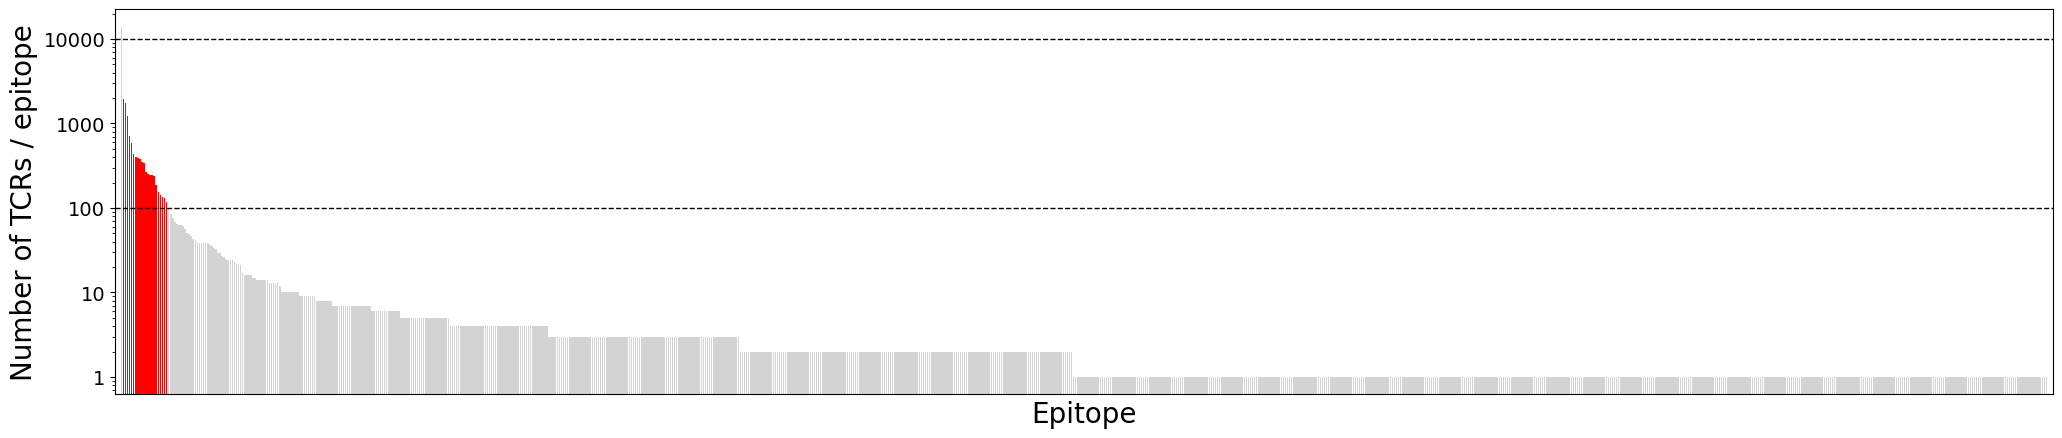

In [11]:
f, ax = plt.subplots(figsize = (25,5))

plt.bar(x = epitope_counts['index'], height = epitope_counts['Epitope'], 
            color=['lightgrey' if c >= 10000 else 'r' if c > 100 else 'lightgrey' for c in epitope_counts['Epitope']])
plt.yscale('log')
ax.set_xticklabels(labels = ['']*epitope_counts.shape[0])
ax.set_xticks([])
ax.axhline(100, ls = '--', c = 'k', lw = 1)
ax.axhline(10000, ls = '--', c = 'k', lw = 1)
ax.set_ylabel('Number of TCRs / epitope', fontsize = 20)
ax.set_xlabel('Epitope', fontsize = 20)
ylabels = [1, 10, 100, 1000, 10000]
ax.set_yticks(ticks = ylabels, labels = ylabels, fontsize = 14)
ax.set_xlim(-3,len(epitope_counts)+2)
plt.savefig(output_folder + 'epitope_size_distribution.pdf', bbox_inches = 'tight')
plt.show()